In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Circle
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform
from matplotlib.patches import Patch
import os
import matplotlib.cm as cm
from matplotlib.colors import Normalize  
from scipy.stats import shapiro

# Importation des données

In [2]:
df_final_clean = pd.read_excel("fichier_final.xlsx")

In [3]:
df_final_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 10 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Country Code                                           107 non-null    object 
 1   PIB_par_habitant 2022                                  107 non-null    float64
 2   Croissance du PIB par habitant_2022                    107 non-null    float64
 3   Population totale Année 2022                           107 non-null    float64
 4   Production Brute 2014-2016 (millier Int$)_2022         107 non-null    int64  
 5   Inflation_prix à la consommation (pourcentage_annuel)  107 non-null    float64
 6   Dépendance_import_2022                                 107 non-null    float64
 7   Disponibilite_Totale_Volailles_Mt                      107 non-null    int64  
 8   Ratio_Conso_Volaille_2022                         

In [4]:
df_final_clean.describe()

,PIB_par_habitant 2022,Croissance du PIB par habitant_2022,Population totale Année 2022,Production Brute 2014-2016 (millier Int$)_2022,Inflation_prix à la consommation (pourcentage_annuel),Dépendance_import_2022,Disponibilite_Totale_Volailles_Mt,Ratio_Conso_Volaille_2022,Déficit_Poulet_2022_Mt
count,107.000000,107.000000,1.070000e+02,1.070000e+02,107.000000,107.000000,107.000000,107.000000,107.000000
mean,13837.143134,3.555017,5.655063e+07,1.694739e+09,13.394017,36.748146,984.205607,1.424993,-33.654206
std,21481.762262,7.572251,1.979650e+08,5.364695e+09,21.501105,38.680260,3198.356048,1.526877,613.647663
min,357.261153,-22.745681,4.670900e+04,2.000000e+03,-1.610680,0.000000,2.000000,0.073677,-4549.000000
25%,2323.960520,1.514894,2.732039e+06,1.925200e+07,5.432042,1.914701,41.500000,0.505751,1.000000
50%,5986.636949,2.889661,1.046387e+07,1.713010e+08,7.922049,19.812878,123.000000,0.942008,9.000000
75%,13037.214978,4.770585,3.408547e+07,7.347470e+08,11.219924,74.133811,482.000000,1.692886,48.000000
max,109269.520580,62.111071,1.425423e+09,3.812313e+10,171.205491,143.181818,25027.000000,8.064815,1150.000000


# Gestion des outliers par normalisation

In [5]:
# Création des variables "par habitant" (Division)
# Transformation des stocks totaux en quantités par personne

df_final_clean['Production_brute_par_habitant'] = (
    df_final_clean['Production Brute 2014-2016 (millier Int$)_2022'] / 
    df_final_clean['Population totale Année 2022']
)

df_final_clean['Dispo_Volailles_par_habitant'] = (
    df_final_clean['Disponibilite_Totale_Volailles_Mt'] / 
    df_final_clean['Population totale Année 2022']
)

df_final_clean['Déficit_Poulet_par_habitant'] = (
    df_final_clean['Déficit_Poulet_2022_Mt'] / 
    df_final_clean['Population totale Année 2022']
)

# Réduction de l'écart des extrêmes pour le PIB et l'Inflation
df_final_clean['Log_PIB_habitant'] = np.log1p(df_final_clean['PIB_par_habitant 2022'])
df_final_clean['Log_Inflation'] = np.log1p(df_final_clean['Inflation_prix à la consommation (pourcentage_annuel)'])


variables_analyse_finale = [
    'Log_PIB_habitant',
    'Croissance du PIB par habitant_2022',
    'Population totale Année 2022',
    'Production_brute_par_habitant',
    'Ratio_Conso_Volaille_2022',
    'Log_Inflation',
    'Dépendance_import_2022',
    'Dispo_Volailles_par_habitant',
    'Déficit_Poulet_par_habitant'
]

print(f"Variables prêtes pour l'analyse : {variables_analyse_finale}")

Variables prêtes pour l'analyse : ['Log_PIB_habitant', 'Croissance du PIB par habitant_2022', 'Population totale Année 2022', 'Production_brute_par_habitant', 'Ratio_Conso_Volaille_2022', 'Log_Inflation', 'Dépendance_import_2022', 'Dispo_Volailles_par_habitant', 'Déficit_Poulet_par_habitant']


/Users/macherie/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


# Standardisation (Mise à l'Échelle) : Utilisation du StandardScaler de Scikit-learn

In [6]:
variables_a_standardiser = [
    'Log_PIB_habitant',
    'Croissance du PIB par habitant_2022',
    'Production_brute_par_habitant',
    'Ratio_Conso_Volaille_2022',
    'Log_Inflation',
    'Dépendance_import_2022',
    'Dispo_Volailles_par_habitant',
    'Déficit_Poulet_par_habitant'
]

# 2. Nettoyage des données manquantes (Indispensable pour la standardisation)
# L'ACP et le K-Means ne fonctionnent pas s'il y a des NaN
df_prep = df_final_clean[variables_a_standardiser].dropna()

# 3. Initialisation du StandardScaler
scaler = StandardScaler()

# 4. Calcul (fit) et Transformation (transform)
data_scaled = scaler.fit_transform(df_prep)

# 5. Conversion en DataFrame pour garder les noms de colonnes et de pays
df_scaled = pd.DataFrame(data_scaled, index=df_prep.index, columns=variables_a_standardiser)

print("Standardisation terminée !")
print(f"Nombre de pays conservés (sans NaN) : {len(df_scaled)}")
display(df_scaled.head())
print(df_scaled.describe().loc[['mean', 'std']].round(2))

Standardisation terminée !
Nombre de pays conservés (sans NaN) : 106


,Log_PIB_habitant,Croissance du PIB par habitant_2022,Production_brute_par_habitant,Ratio_Conso_Volaille_2022,Log_Inflation,Dépendance_import_2022,Dispo_Volailles_par_habitant,Déficit_Poulet_par_habitant
0,-2.134150,-1.471410,-0.885119,-0.738898,0.541650,-0.458205,-1.202671,-0.511149
1,-0.528611,-0.489715,-0.820910,-0.583523,1.114222,1.236529,-0.766629,-0.058146
2,0.119671,0.336074,-0.852814,-0.436929,-0.339917,0.914302,-0.196757,0.345832
3,1.636915,-0.183347,-0.691849,1.941955,-0.620915,2.037790,1.210021,2.048639
4,0.662546,0.195978,1.943895,-0.616057,2.741756,-0.946474,0.955147,-0.712889


      Log_PIB_habitant  Croissance du PIB par habitant_2022  \
mean              -0.0                                 -0.0   
std                1.0                                  1.0   

      Production_brute_par_habitant  Ratio_Conso_Volaille_2022  Log_Inflation  \
mean                            0.0                       -0.0           -0.0   
std                             1.0                        1.0            1.0   

      Dépendance_import_2022  Dispo_Volailles_par_habitant  \
mean                     0.0                           0.0   
std                      1.0                           1.0   

      Déficit_Poulet_par_habitant  
mean                          0.0  
std                           1.0  


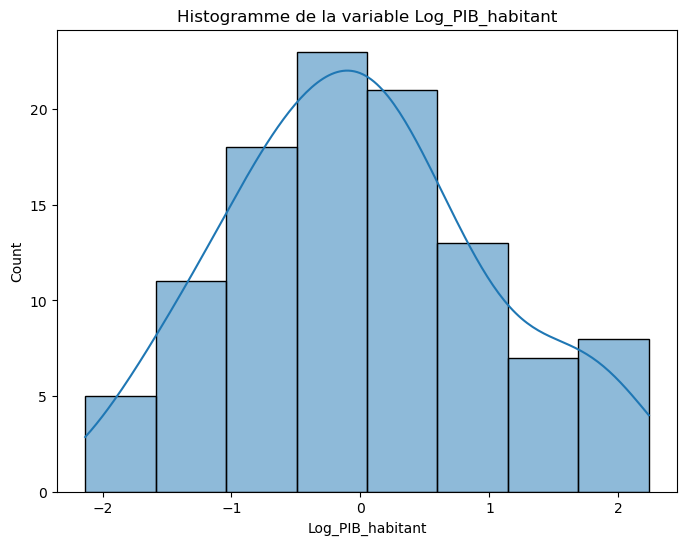

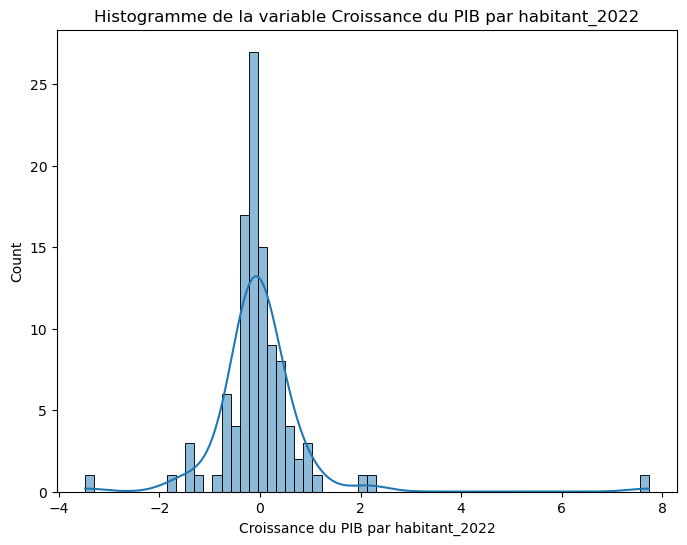

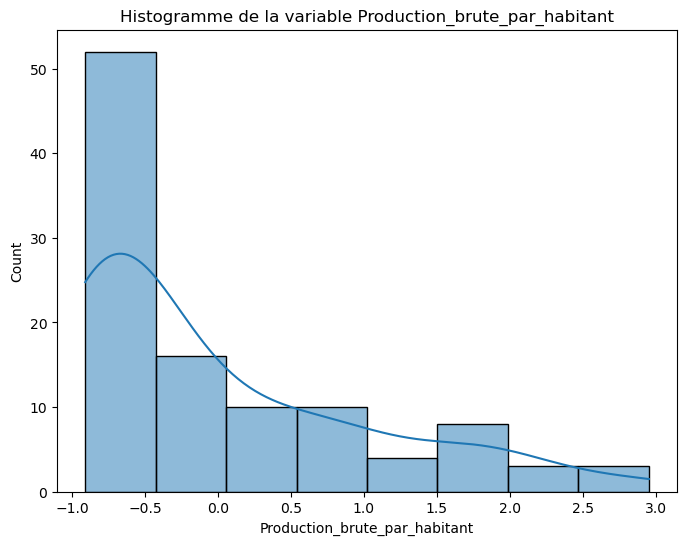

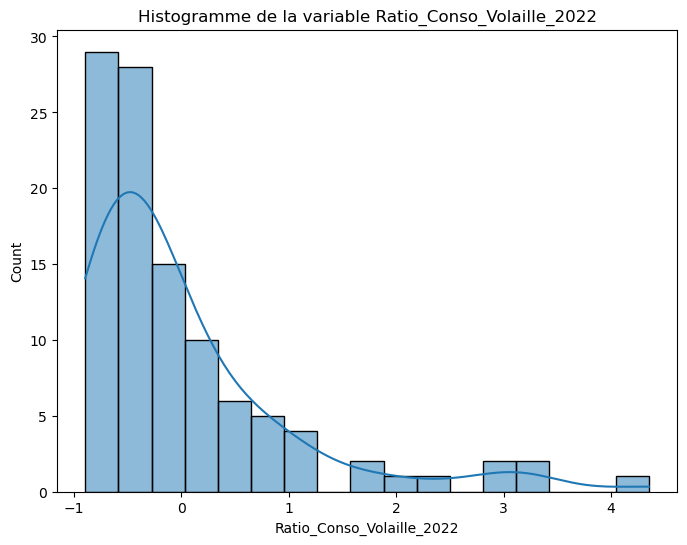

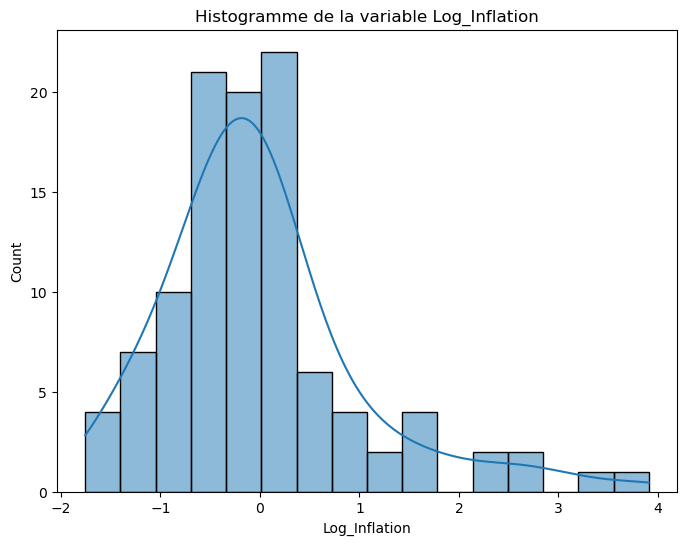

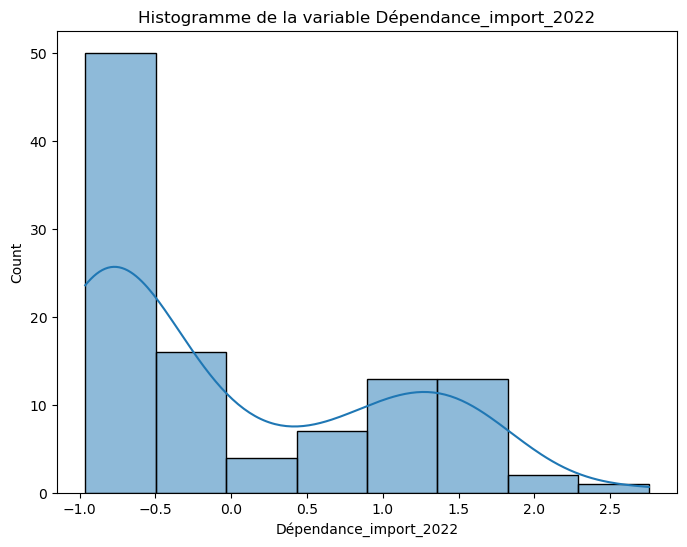

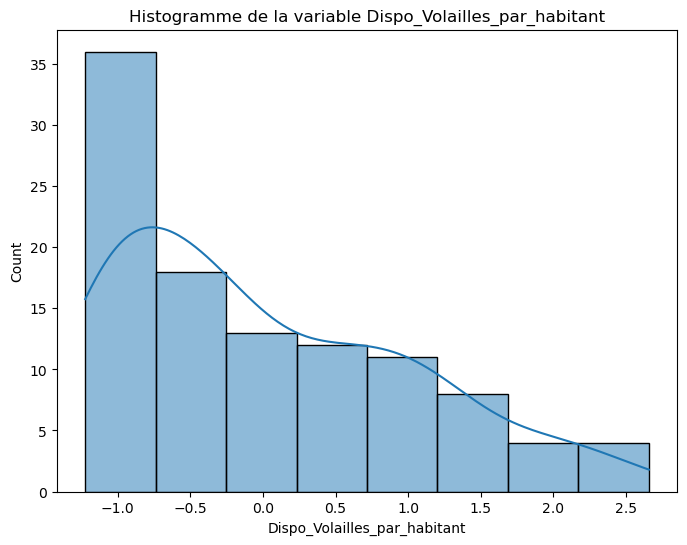

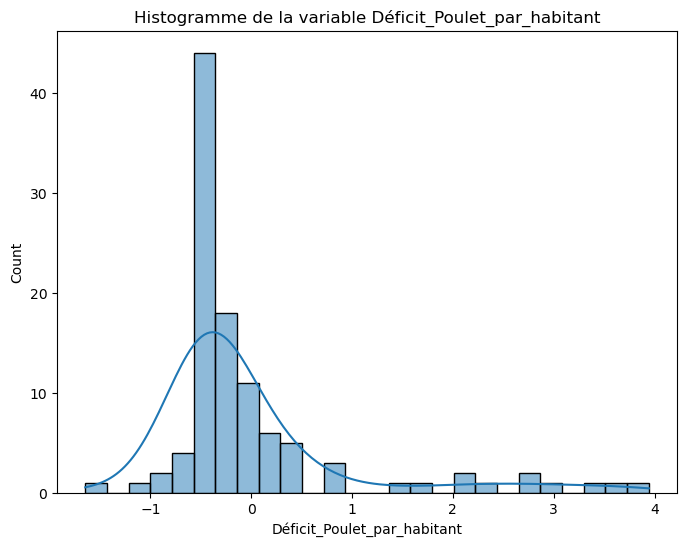

In [7]:
# Analyse de la normalité
from scipy.stats import shapiro

# Création d'un histogramme et d'un test de normalité pour chaque variable
for column in variables_a_standardiser:
    plt.figure(figsize=(8, 6))
    sns.histplot(data=df_scaled, x=column, kde=True)
    plt.title(f"Histogramme de la variable {column}")
    plt.show()

# Analayse Multidimensionnelle

## Analyse en Composantes Principales (ACP)

In [8]:
# Création du modèle PCA
pca = PCA(n_components=8)  # Garder toutes les composantes
pca.fit(df_scaled)

print("\n" + "="*60)
print("ACP INITIALISÉE")
print("="*60)
print(f"Nombre de variables : {pca.n_features_in_}")
print(f"Nombre de composantes : {pca.n_components_}")
print(f"Variance totale expliquée : {pca.explained_variance_ratio_.sum():.1%}")


ACP INITIALISÉE
Nombre de variables : 8
Nombre de composantes : 8
Variance totale expliquée : 100.0%


### Choix du nombre d'axe factoriel

#### Analyse des Valeurs Propres (Variance Expliquée)

In [9]:
# Valeurs propres (variance expliquée par chaque composante)
valeurs_propres = pca.explained_variance_

# Pourcentage de variance expliquée par chaque composante
pourcentage_variance = pca.explained_variance_ratio_

# Pourcentage de variance expliquée cumulée
pourcentage_cumule = np.cumsum(pourcentage_variance)

# Création d'un DataFrame récapitulatif
resume_pca = pd.DataFrame({
    'Composante': range(1, len(valeurs_propres) + 1),
    'Valeur Propre (Variance)': valeurs_propres.round(2),
    'Pourcentage Expliqué (%)': (pourcentage_variance * 100).round(2),
    'Pourcentage Cumulé (%)': (pourcentage_cumule * 100).round(2)
})

print("\n" + "="*60)
print("RÉSUMÉ DE LA VARIANCE EXPLIQUÉE PAR COMPOSANTE")
print("="*60)
print(resume_pca.to_string(index=False))


RÉSUMÉ DE LA VARIANCE EXPLIQUÉE PAR COMPOSANTE
 Composante  Valeur Propre (Variance)  Pourcentage Expliqué (%)  Pourcentage Cumulé (%)
          1                      2.77                     34.26                   34.26
          2                      2.07                     25.67                   59.93
          3                      0.94                     11.68                   71.60
          4                      0.86                     10.67                   82.27
          5                      0.80                      9.88                   92.15
          6                      0.39                      4.86                   97.02
          7                      0.24                      2.94                   99.96
          8                      0.00                      0.04                  100.00


### Critères de Sélection des Composantes


Il existe donc 2 grandes dimensions dominantes :

PC1 (34,26% d’information)

PC2 (25,67%)

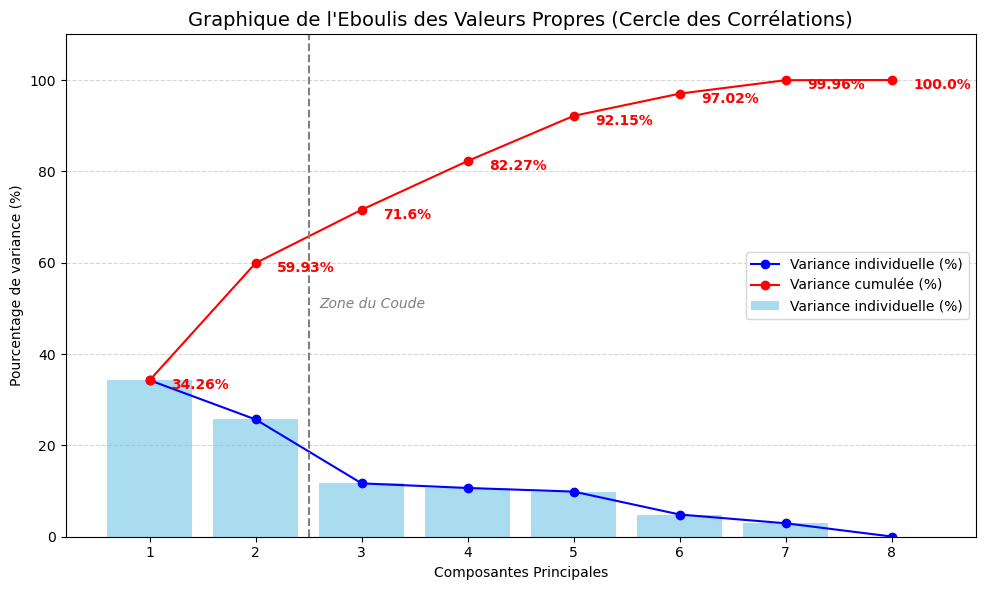

In [10]:
# Configuration du style
plt.figure(figsize=(10, 6))

# 1. Barres : Variance individuelle par composante
plt.bar(resume_pca['Composante'], resume_pca['Pourcentage Expliqué (%)'], 
        alpha=0.7, color='skyblue', label='Variance individuelle (%)')

# 2. Ligne : Variance individuelle par composante
plt.plot(resume_pca['Composante'], resume_pca['Pourcentage Expliqué (%)'], 
        marker='o', linestyle='-', color='blue', label='Variance individuelle (%)')
# 2. Ligne : Variance cumulée
plt.plot(resume_pca['Composante'], resume_pca['Pourcentage Cumulé (%)'], 
         marker='o', linestyle='-', color='red', label='Variance cumulée (%)')

# 3. Ajout des étiquettes de texte sur les points
for i, val in enumerate(resume_pca['Pourcentage Cumulé (%)']):
    plt.text(i+1.2, val-2, f"{val}%", color='red', fontweight='bold')

# Personnalisation des axes
plt.xlabel('Composantes Principales')
plt.ylabel('Pourcentage de variance (%)')
plt.title('Graphique de l\'Eboulis des Valeurs Propres (Cercle des Corrélations)', fontsize=14)
plt.xticks(resume_pca['Composante'])
plt.ylim(0, 110) # Pour bien voir la ligne des 100%
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='center right')

# Affichage de la ligne du "Coude"
plt.axvline(x=2.5, color='gray', linestyle='--') 
plt.text(2.6, 50, 'Zone du Coude', color='gray', style='italic')

plt.tight_layout()
plt.show()

## Choix des axes factoriels

In [11]:
resume_pca.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Composante                8 non-null      int64  
 1   Valeur Propre (Variance)  8 non-null      float64
 2   Pourcentage Expliqué (%)  8 non-null      float64
 3   Pourcentage Cumulé (%)    8 non-null      float64
dtypes: float64(3), int64(1)
memory usage: 388.0 bytes


## Représentation du cercle de corrélation (Biplot)

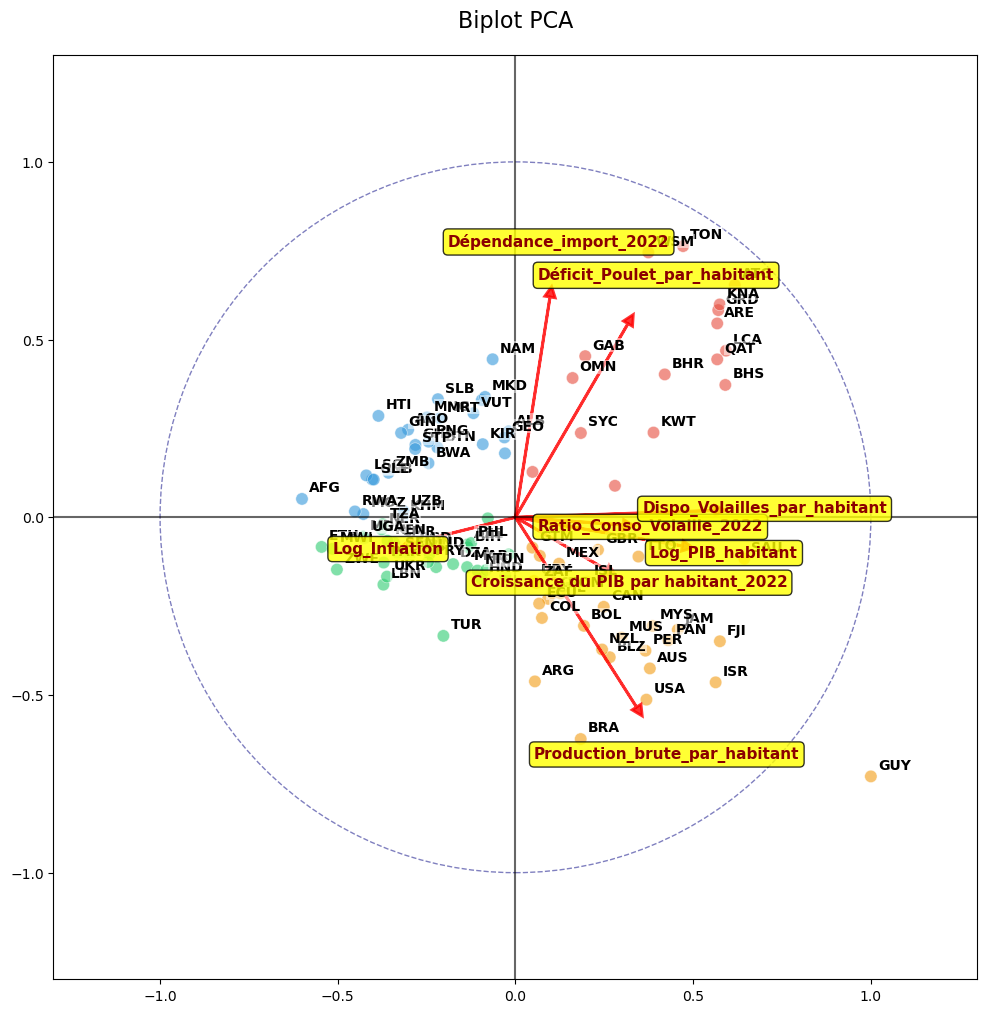

In [12]:
# 1. Calcul PCA et Coordonnées
X_scaled = df_scaled[variables_a_standardiser].values
pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(X_scaled)

# 2. Calcul de la Qualité de Représentation (Cos2)

cos2 = (pca_transformed**2).sum(axis=1) / ((X_scaled**2).sum(axis=1))

# 3. Normalisation pour le cercle
max_abs = np.max(np.abs(pca_transformed))
pays_coords_norm = pca_transformed / max_abs
pcs = pca.components_

# 4. Création de la figure
fig, ax = plt.subplots(figsize=(15, 12), facecolor='white')

# 5. Couleurs par quadrant
colors_quadrant = []
for i in range(len(pays_coords_norm)):
    x, y = pays_coords_norm[i, 0], pays_coords_norm[i, 1]
    if x >= 0 and y >= 0: colors_quadrant.append('#e74c3c') # Q1
    elif x < 0 and y >= 0: colors_quadrant.append('#3498db') # Q2
    elif x < 0 and y < 0: colors_quadrant.append('#2ecc71')  # Q3
    else: colors_quadrant.append('#f39c12')                 # Q4

# 6. Affichage des points (Tous les pays)
ax.scatter(pays_coords_norm[:, 0], pays_coords_norm[:, 1], 
           c=colors_quadrant, alpha=0.6, s=80, edgecolors='white', linewidth=0.5)

# 7. AFFICHAGE SÉLECTIF DES NOMS (Top Qualité)
country_codes = df_final_clean.loc[df_scaled.index, 'Country Code']
seuil_cos2 = np.percentile(cos2, 10) # On n'affiche que les 70% des pays les mieux représentés

for i, code in enumerate(country_codes):
    if cos2[i] >= seuil_cos2:
        ax.text(pays_coords_norm[i, 0] + 0.02, pays_coords_norm[i, 1] + 0.02, str(code), 
                fontsize=10, fontweight='bold', color='black', 
                bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=0.1))

# 8. Variables (Flèches et Étiquettes)
for i, (x, y) in enumerate(zip(pcs[0, :], pcs[1, :])):
    ax.arrow(0, 0, x, y, head_width=0.03, head_length=0.03, color='red', alpha=0.8, lw=2)
    ax.text(x * 1.25, y * 1.25, variables_a_standardiser[i], 
            color='darkred', ha='center', va='center', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.8))

# 9. Finitions (Cercle, Axes, Légende)
circle = plt.Circle((0, 0), 1, facecolor='none', edgecolor='navy', linestyle='--', alpha=0.5)
ax.add_artist(circle)
ax.axhline(0, color='black', alpha=0.6)
ax.axvline(0, color='black', alpha=0.6)
ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3); ax.set_aspect('equal')

plt.title("Biplot PCA", fontsize=16, pad=20)
plt.savefig('biplot_pca_final_style.png', dpi=300, bbox_inches='tight')
plt.show()

# K-MEANS & VISUALISATION DES CLUSTERS

## STANDARDISATION

In [29]:
variables_a_standardiser = [
    'Log_PIB_habitant',
    'Croissance du PIB par habitant_2022',
    'Production_brute_par_habitant',
    'Ratio_Conso_Volaille_2022',
    'Log_Inflation',
    'Dépendance_import_2022',
    'Dispo_Volailles_par_habitant',
    'Déficit_Poulet_par_habitant'
]

# 2. Nettoyage des données manquantes

df_prep = df_final_clean[variables_a_standardiser].dropna()

# 3. Initialisation du StandardScaler
scaler = StandardScaler()

# 4. Calcul (fit) et Transformation (transform)
data_scaled = scaler.fit_transform(df_prep)

# 5. Conversion en DataFrame 
df_scaled = pd.DataFrame(data_scaled, index=df_prep.index, columns=variables_a_standardiser)
display(df_scaled.head())
print(df_scaled.describe().loc[['mean', 'std']].round(2))

,Log_PIB_habitant,Croissance du PIB par habitant_2022,Production_brute_par_habitant,Ratio_Conso_Volaille_2022,Log_Inflation,Dépendance_import_2022,Dispo_Volailles_par_habitant,Déficit_Poulet_par_habitant
0,-2.134150,-1.471410,-0.885119,-0.738898,0.541650,-0.458205,-1.202671,-0.511149
1,-0.528611,-0.489715,-0.820910,-0.583523,1.114222,1.236529,-0.766629,-0.058146
2,0.119671,0.336074,-0.852814,-0.436929,-0.339917,0.914302,-0.196757,0.345832
3,1.636915,-0.183347,-0.691849,1.941955,-0.620915,2.037790,1.210021,2.048639
4,0.662546,0.195978,1.943895,-0.616057,2.741756,-0.946474,0.955147,-0.712889


      Log_PIB_habitant  Croissance du PIB par habitant_2022  \
mean              -0.0                                 -0.0   
std                1.0                                  1.0   

      Production_brute_par_habitant  Ratio_Conso_Volaille_2022  Log_Inflation  \
mean                            0.0                       -0.0           -0.0   
std                             1.0                        1.0            1.0   

      Dépendance_import_2022  Dispo_Volailles_par_habitant  \
mean                     0.0                           0.0   
std                      1.0                           1.0   

      Déficit_Poulet_par_habitant  
mean                          0.0  
std                           1.0  


## Détermination du K-optimal

Graphiques de validation enregistrés sous 'validation_clusters_kmeans.png'


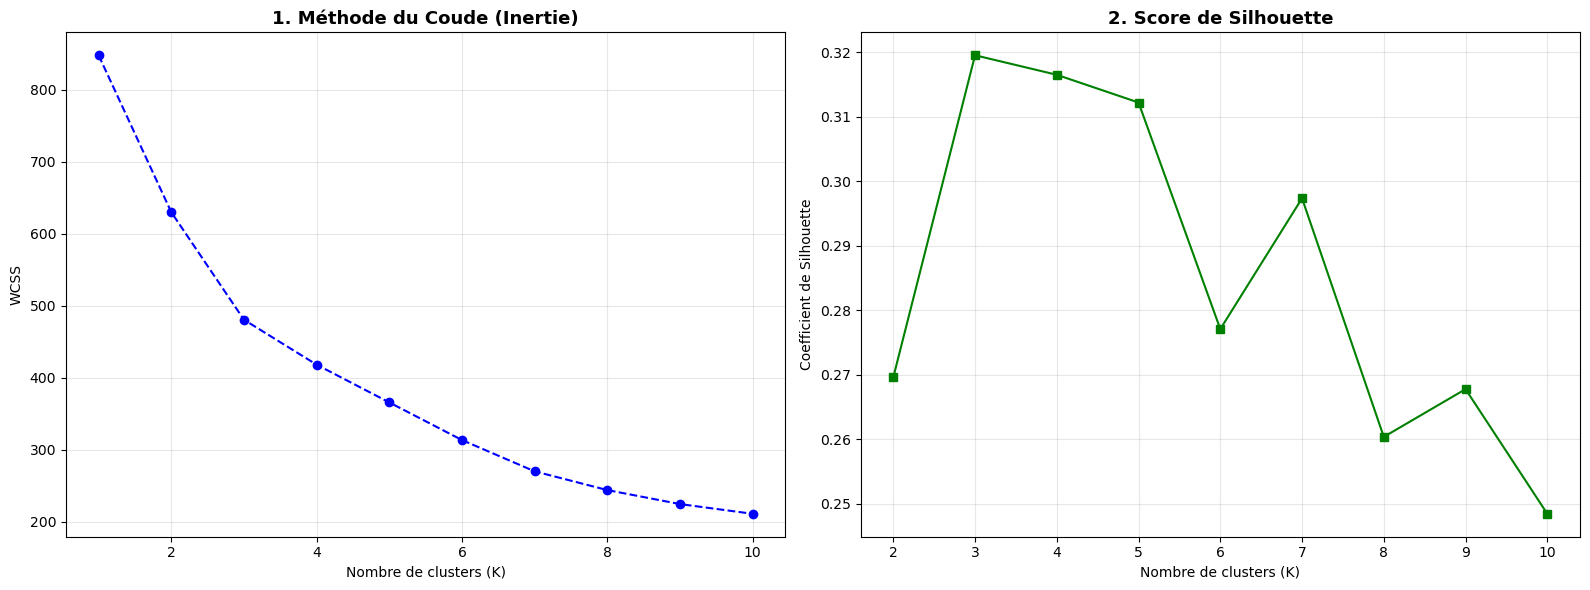

In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# Configuration de la figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- MÉTHODE 1 : LE COUDE (ELBOW METHOD) ---
wcss = []
range_k = range(1, 11)
for k in range_k:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

ax1.plot(range_k, wcss, marker='o', linestyle='--', color='b')
ax1.set_title('1. Méthode du Coude (Inertie)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Nombre de clusters (K)')
ax1.set_ylabel('WCSS')
ax1.grid(True, alpha=0.3)

# --- MÉTHODE 2 : SCORE DE SILHOUETTE ---
sil_scores = []
range_k_sil = range(2, 11) 
for k in range_k_sil:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    sil_scores.append(silhouette_score(df_scaled, labels))

ax2.plot(range_k_sil, sil_scores, marker='s', linestyle='-', color='g')
ax2.set_title('2. Score de Silhouette', fontsize=13, fontweight='bold')
ax2.set_xlabel('Nombre de clusters (K)')
ax2.set_ylabel('Coefficient de Silhouette')
ax2.grid(True, alpha=0.3)

# --- ENREGISTREMENT DE L'IMAGE ---
plt.tight_layout()
# On enregistre avant plt.show() pour éviter une image vide
plt.savefig('validation_clusters_kmeans.png', dpi=300, bbox_inches='tight')
print("Graphiques de validation enregistrés sous 'validation_clusters_kmeans.png'")

plt.show()

In [15]:
# Application du K-Means
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_scaled)

# Ajout des résultats au DataFrame initial pour analyse
df_final_clean.loc[df_scaled.index, 'Cluster'] = clusters

In [16]:
# Moyennes de chaque groupe

print(df_final_clean.groupby('Cluster').mean(numeric_only=True))

# Taille de chaque groupe
print(df_final_clean['Cluster'].value_counts())

         PIB_par_habitant 2022  Croissance du PIB par habitant_2022  \
Cluster                                                               
0.0               26143.676995                             3.744804   
1.0                3266.955206                             2.177810   
2.0               26326.772508                             5.750157   

         Population totale Année 2022  \
Cluster                                 
0.0                      1.978364e+06   
1.0                      5.311304e+07   
2.0                      8.354403e+07   

         Production Brute 2014-2016 (millier Int$)_2022  \
Cluster                                                   
0.0                                        2.120343e+07   
1.0                                        5.416915e+08   
2.0                                        4.191175e+09   

         Inflation_prix à la consommation (pourcentage_annuel)  \
Cluster                                                          
0.0       

### Profilage des Clusters

In [17]:
# 1. Calcul des moyennes par cluster pour toutes les variables d'analyse
# On utilise les données non-standardisées si possible pour une lecture plus facile (ex: en $, en tonnes)
profil_clusters = df_final_clean.groupby('Cluster')[variables_a_standardiser].mean()

# 2. Ajout du nombre de pays par cluster pour voir la taille du segment
profil_clusters['Nb_Pays'] = df_final_clean.groupby('Cluster').size()

# 3. Affichage du tableau de bord des clusters
print("CARACTÉRISTIQUES DES SEGMENTS MARCHÉS :")
display(profil_clusters.round(2))

# Sauvegarde pour votre rapport Word/Excel
profil_clusters.to_excel("profil_segments_export.xlsx")

CARACTÉRISTIQUES DES SEGMENTS MARCHÉS :


,Log_PIB_habitant,Croissance du PIB par habitant_2022,Production_brute_par_habitant,Ratio_Conso_Volaille_2022,Log_Inflation,Dépendance_import_2022,Dispo_Volailles_par_habitant,Déficit_Poulet_par_habitant,Nb_Pays
Cluster,,,,,,,,,
0.0,9.84,3.74,10.84,2.06,1.75,92.24,0.0,0.0,14
1.0,7.78,2.18,11.68,0.95,2.61,39.02,0.0,0.0,57
2.0,9.66,5.75,71.46,1.97,2.00,11.90,0.0,0.0,35


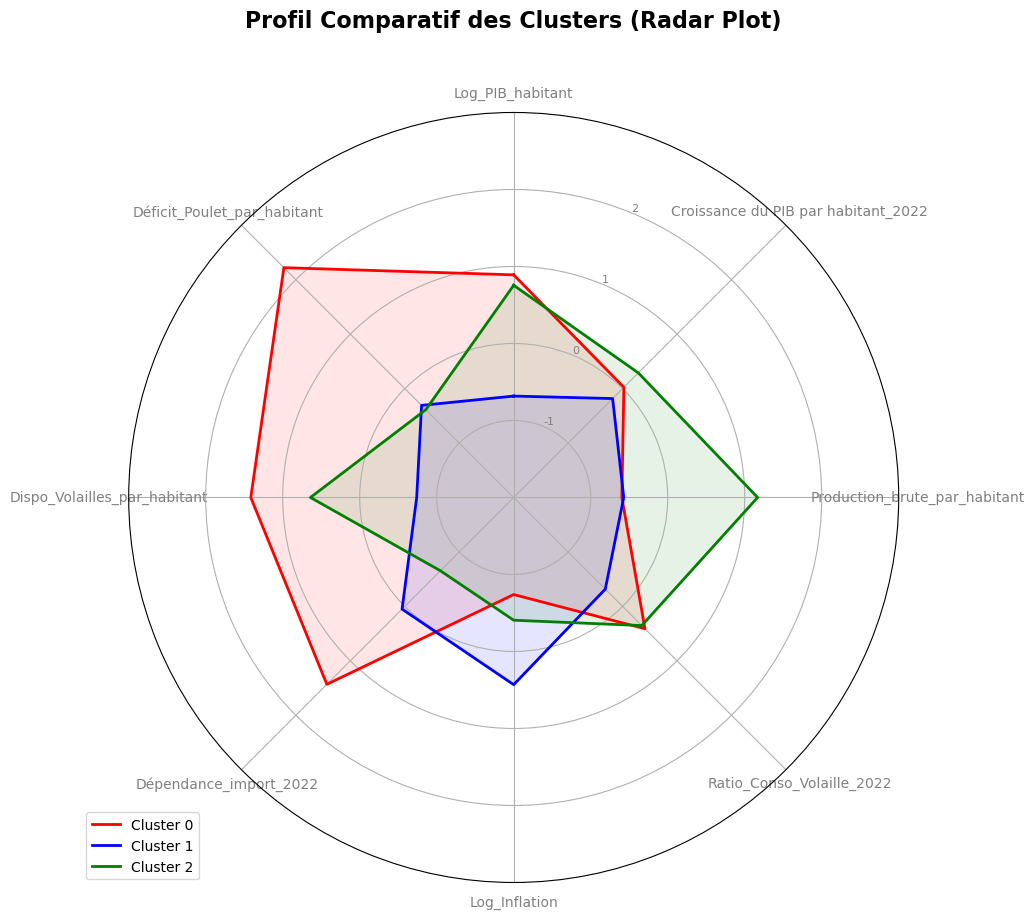

In [18]:
from math import pi

# 1. Calcul des moyennes par cluster sur les données standardisées
df_radar = df_scaled.copy()
df_radar['Cluster'] = clusters
cluster_means = df_radar.groupby('Cluster').mean()

# 2. Paramètres du graphique
categories = list(cluster_means.columns)
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1] # Fermer le cercle

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# 3. Tracer chaque cluster
colors = ['red', 'blue', 'green', 'orange', 'purple']
for i in range(len(cluster_means)):
    values = cluster_means.iloc[i].values.flatten().tolist()
    values += values[:1] # Fermer le cercle
    
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=f'Cluster {i}', color=colors[i])
    ax.fill(angles, values, color=colors[i], alpha=0.1)

# 4. Habillage
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], categories, color='grey', size=10)
plt.yticks([-1, 0, 1, 2], ["-1", "0", "1", "2"], color="grey", size=8) # Échelle standardisée
plt.ylim(-2, 3)

plt.title('Profil Comparatif des Clusters (Radar Plot)', size=16, fontweight='bold', y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

# 5. Enregistrement
plt.savefig('radar_plot_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

### Représentation stratégiques des clusters

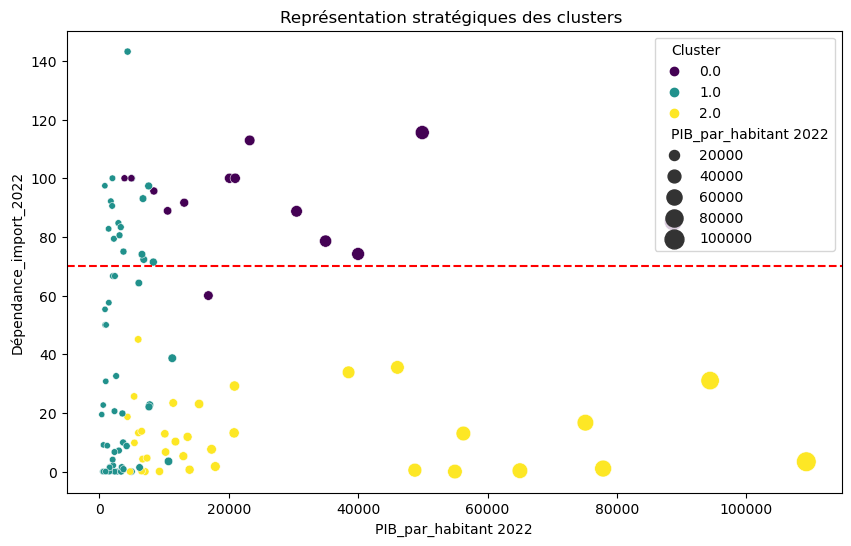

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final_clean, 
                x='PIB_par_habitant 2022', 
                y='Dépendance_import_2022', 
                hue='Cluster', 
                size='PIB_par_habitant 2022',
                palette='viridis',
                sizes=(20, 200))

plt.title('Représentation stratégiques des clusters ')
plt.axhline(y=70, color='r', linestyle='--') # Seuil de forte dépendance
plt.savefig('scatterplot.png', dpi=300, bbox_inches='tight')
plt.show()

### zoom sur le cluster 0

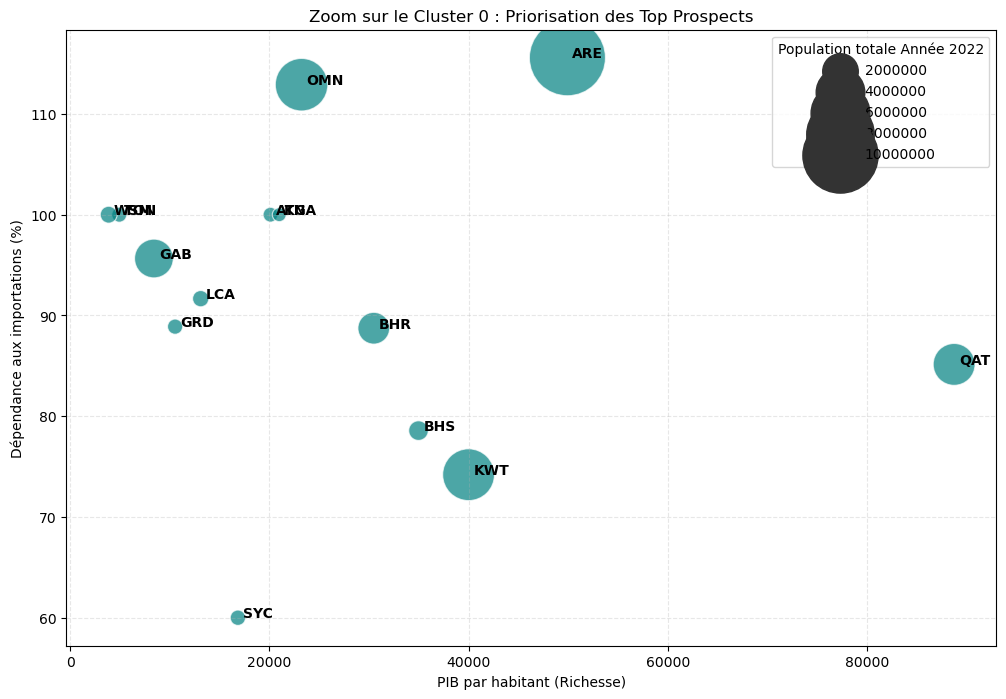

In [20]:

# 1. On filtre les données pour ne garder que le cluster 0
df_cluster_0 = df_final_clean[df_final_clean['Cluster'] == 0]

plt.figure(figsize=(12, 8))

# 2. On trace le scatterplot uniquement sur ce filtre
# J'ai remplacé hue='Cluster' par hue='Country Code' ou une autre variable 
# car ici, tout le monde appartient au même cluster.
sns.scatterplot(data=df_cluster_0, 
                x='PIB_par_habitant 2022', 
                y='Dépendance_import_2022', 
                size='Population totale Année 2022', 
                sizes=(100, 3000), # On augmente un peu la taille pour la visibilité
                alpha=0.7, 
                legend='brief',
                color='teal') # Couleur unique pour le cluster 0

# 3. Ajout des noms des pays (tous ceux du cluster 0 puisqu'on a filtré)
for i in range(df_cluster_0.shape[0]):
    plt.text(x=df_cluster_0['PIB_par_habitant 2022'].iloc[i] + 500, # petit décalage x pour lisibilité
             y=df_cluster_0['Dépendance_import_2022'].iloc[i], 
             s=df_cluster_0['Country Code'].iloc[i],
             fontsize=10,
             fontweight='semibold')

plt.title('Zoom sur le Cluster 0 : Priorisation des Top Prospects')
plt.xlabel('PIB par habitant (Richesse)')
plt.ylabel('Dépendance aux importations (%)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.savefig('scatterplotcluster0.png', dpi=300, bbox_inches='tight')
plt.show()

### Extraction de la Liste de Prospection (Le Cluster "Cible")

In [21]:
# Remplacer '0' par le numéro du cluster qui vous intéresse (Haut-Droit du Biplot)
cluster_cible = 0 

# Extraction des pays prioritaires
liste_prospects = df_final_clean[df_final_clean['Cluster'] == cluster_cible].copy()

# Tri par déficit par habitant pour avoir les meilleurs en premier
liste_prospects = liste_prospects.sort_values(by='Dépendance_import_2022', ascending=False)

# Affichage des 15 premiers pays
print(f"TOP PROSPECTS DU CLUSTER {cluster_cible} :")
display(liste_prospects[['Country Code', 'Population totale Année 2022', 'Dépendance_import_2022']].sort_values(by='Population totale Année 2022', ascending= False))

liste_prospects.to_csv("liste_prioritaire_exportation.csv", index=False)

TOP PROSPECTS DU CLUSTER 0 :


,Country Code,Population totale Année 2022,Dépendance_import_2022
3,ARE,10242086.0,115.579710
75,OMN,4730226.0,112.903226
53,KWT,4589511.0,74.193548
82,QAT,2892455.0,85.142857
30,GAB,2430747.0,95.652174
10,BHR,1533459.0,88.732394
11,BHS,397538.0,78.571429
103,WSM,215261.0,100.000000
56,LCA,178781.0,91.666667
90,SYC,125522.0,60.000000


In [22]:
# Remplacer '0' par le numéro du cluster qui vous intéresse (Haut-Droit du Biplot)
cluster_cible = 1 

# Extraction des pays prioritaires
liste_prospects = df_final_clean[df_final_clean['Cluster'] == cluster_cible].copy()

# Tri par déficit par habitant pour avoir les meilleurs en premier
liste_prospects = liste_prospects.sort_values(by='Dépendance_import_2022', ascending=False)

# Affichage des 15 premiers pays
print(f"TOP PROSPECTS DU CLUSTER {cluster_cible} :")
display(liste_prospects[['Country Code', 'Population totale Année 2022', 'Dépendance_import_2022']].sort_values(by='Population totale Année 2022', ascending= False))

liste_prospects.to_csv("liste_prioritaire_exportation.csv", index=False)

TOP PROSPECTS DU CLUSTER 1 :


,Country Code,Population totale Année 2022,Dépendance_import_2022
43,IND,1.425423e+09,0.000000
76,PAK,2.437007e+08,0.000000
9,BGD,1.693849e+08,0.000000
28,ETH,1.253843e+08,0.000000
79,PHL,1.139643e+08,19.812878
95,TUR,8.705847e+07,3.488372
96,TZA,6.471182e+07,8.823529
49,KEN,5.425246e+07,2.105263
97,UGA,4.731272e+07,0.000000
26,DZA,4.547739e+07,0.000000


### Calcul de score de priorité

In [23]:

cluster_0 = df_final_clean[df_final_clean['Cluster'] == 0].copy()

cluster_0.sort_values(by='Population totale Année 2022', ascending= False)



,Country Code,PIB_par_habitant 2022,Croissance du PIB par habitant_2022,Population totale Année 2022,Production Brute 2014-2016 (millier Int$)_2022,Inflation_prix à la consommation (pourcentage_annuel),Dépendance_import_2022,Disponibilite_Totale_Volailles_Mt,Ratio_Conso_Volaille_2022,Déficit_Poulet_2022_Mt,Production_brute_par_habitant,Dispo_Volailles_par_habitant,Déficit_Poulet_par_habitant,Log_PIB_habitant,Log_Inflation,Cluster
3,ARE,49899.065298,2.176083,10242086.0,77005000,5.291226,115.579710,552,4.393575,505,7.518488,0.000054,0.000049,10.817778,1.839156,0.0
75,OMN,23223.582941,2.739588,4730226.0,12953000,2.506143,112.903226,93,1.757429,86,2.738347,0.000020,0.000018,10.052967,1.254516,0.0
53,KWT,39981.769098,1.437113,4589511.0,114993000,3.980650,74.193548,186,3.226178,126,25.055610,0.000041,0.000027,10.596204,1.605560,0.0
82,QAT,88701.463352,-1.790979,2892455.0,48201000,4.995276,85.142857,175,2.835014,149,16.664391,0.000061,0.000052,11.393043,1.790972,0.0
30,GAB,8409.207415,0.747534,2430747.0,7976000,4.231248,95.652174,92,1.955976,88,3.281296,0.000038,0.000036,9.037201,1.654650,0.0
10,BHR,30470.521928,4.764512,1533459.0,16318000,3.625741,88.732394,71,2.500721,62,10.641302,0.000046,0.000040,10.324548,1.531637,0.0
11,BHS,34957.161328,10.552524,397538.0,11659000,5.605406,78.571429,28,1.034973,22,29.328014,0.000070,0.000055,10.461907,1.887888,0.0
103,WSM,3869.466395,-5.958225,215261.0,609000,10.961882,100.000000,17,1.640420,17,2.829124,0.000079,0.000079,8.261130,2.481725,0.0
56,LCA,13103.824315,20.214036,178781.0,2488000,6.378147,91.666667,12,1.941588,11,13.916468,0.000067,0.000062,9.480736,1.998523,0.0
90,SYC,16836.672190,-6.676657,125522.0,2715000,2.626036,60.000000,5,1.241686,3,21.629674,0.000040,0.000024,9.731374,1.288140,0.0


# CAH (Classification ascendante hierarchique)

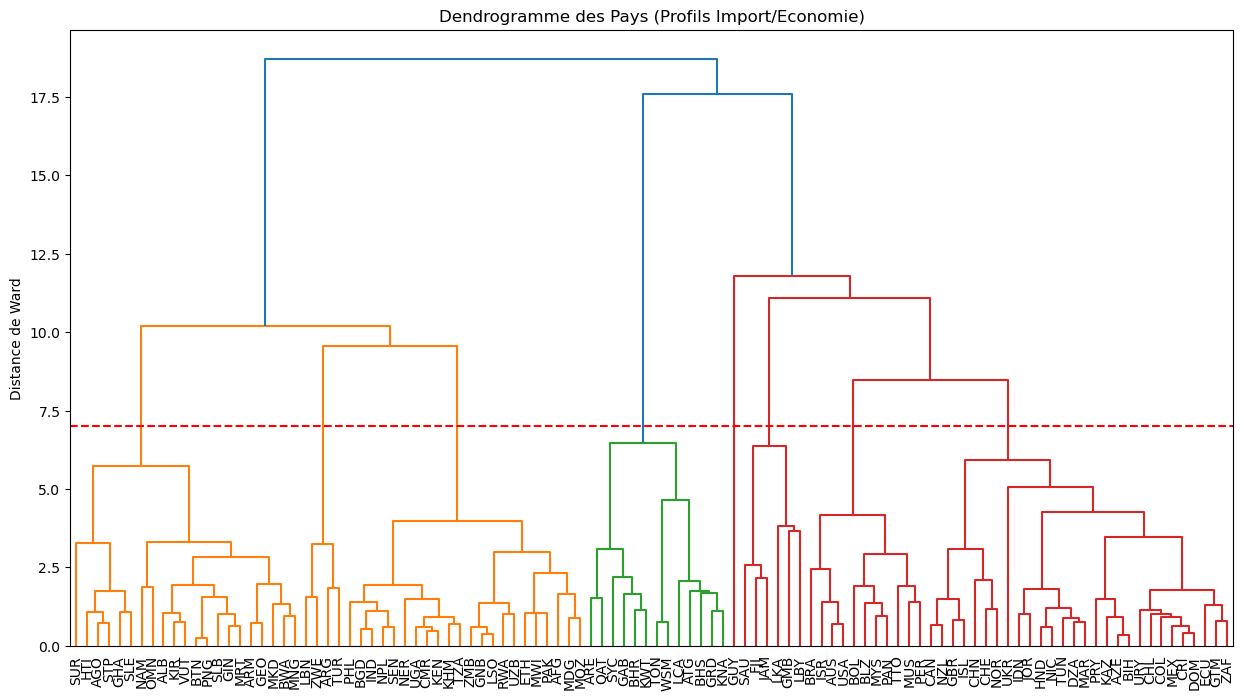

In [24]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Calcul du lien (assurez-vous que X_scaled est bien le tableau final utilisé)
Z = linkage(X_scaled, method='ward')

# 2. Sécurisation des labels : on prend les codes pays 
# UNIQUEMENT pour les index présents dans X_scaled (ou df_scaled)
indices_utilises = df_scaled.index
labels_alignes = df_final_clean.loc[indices_utilises, 'Country Code'].values

# 3. Affichage du Dendrogramme
plt.figure(figsize=(15, 8))
plt.title("Dendrogramme des Pays (Profils Import/Economie)")

dendrogram(
    Z, 
    labels=labels_alignes, # Utilisation des labels filtrés et alignés
    leaf_rotation=90, 
    leaf_font_size=10
)

plt.axhline(y=7, color='r', linestyle='--') 
plt.ylabel('Distance de Ward')

plt.savefig('dendogramme.png', dpi=300, bbox_inches='tight')
plt.show()

In [25]:
# 1. On génère les labels (lignes des pays)
# On utilise t=4 pour correspondre aux 4 groupes du dendrogramme
cah_labels = fcluster(Z, t=4, criterion='maxclust')

# 2. On les injecte dans df_final_clean en utilisant l'index de df_scaled
# Cela garantit que chaque label va sur la bonne ligne de pays
df_final_clean.loc[df_scaled.index, 'Cluster_CAH'] = cah_labels

# 3. Vérification du croisement avec K-means
print("Comparaison des segmentations (Lignes=K-means, Colonnes=CAH) :")
print(pd.crosstab(df_final_clean['Cluster'], df_final_clean['Cluster_CAH']))

Comparaison des segmentations (Lignes=K-means, Colonnes=CAH) :
Cluster_CAH  1.0  2.0  3.0  4.0
Cluster                        
0.0            1   13    0    0
1.0           45    0   12    0
2.0            1    0   33    1


In [26]:
# Trouver le pays qui n'a pas de cluster CAH
pays_manquant = df_final_clean[df_final_clean['Cluster_CAH'].isna()]
print("Pays exclu du clustering :")
print(pays_manquant[['Country Code']])

Pays exclu du clustering :
   Country Code
91          THA


# Top 3 final à court terme après conclusion analyse ACP, Kmeans, CAH 

In [27]:
# Filtrage sur le consensus (K-means 0 + CAH 2.0)
Top_3_final = df_final_clean[(df_final_clean['Cluster'] == 0) & (df_final_clean['Cluster_CAH'] == 2.0)].copy()

# Sélection des colonnes, tri par population décroissante et extraction des 3 premières lignes
Top_3_Pays = Top_3_final[['Country Code', 'Population totale Année 2022', 'Dépendance_import_2022']] \
                .sort_values(by='Population totale Année 2022', ascending=False) \
                .head(3)

display(Top_3_Pays)

,Country Code,Population totale Année 2022,Dépendance_import_2022
3,ARE,10242086.0,115.579710
53,KWT,4589511.0,74.193548
82,QAT,2892455.0,85.142857


In [28]:
coeur_de_cible = df_final_clean[
    (df_final_clean['Cluster'] == 0) & 
    (df_final_clean['Cluster_CAH'] == 2.0)
].copy()

# AFFICHAGE DES RÉSULTATS
print("=== TOP 3 des pays court terme ===")
print(top_3_final[['Country Code', 'Horizon_Strategique', 'PIB_par_habitant 2022', 'Population totale Année 2022', 'Dépendance_import_2022']])



=== TOP 3 des pays court terme ===


NameError: name 'top_3_final' is not defined